# Imports

In [1]:
import os
import torch
import math
from random import randint
from utils.loss_utils import l1_loss, ssim
from gaussian_renderer import render, network_gui
import sys
from scene import Scene, GaussianModel
from utils.general_utils import safe_state, get_expon_lr_func
import uuid
from tqdm import tqdm
from utils.image_utils import psnr
from argparse import ArgumentParser, Namespace
from arguments import ModelParams, PipelineParams, OptimizationParams
try:
    from torch.utils.tensorboard import SummaryWriter
    TENSORBOARD_FOUND = True
except ImportError:
    TENSORBOARD_FOUND = False

try:
    from fused_ssim import fused_ssim
    FUSED_SSIM_AVAILABLE = True
except:
    FUSED_SSIM_AVAILABLE = False

try:
    from diff_gaussian_rasterization import SparseGaussianAdam
    SPARSE_ADAM_AVAILABLE = True
except:
    SPARSE_ADAM_AVAILABLE = False


def prepare_output_and_logger(args):    
    if not args.model_path:
        if os.getenv('OAR_JOB_ID'):
            unique_str=os.getenv('OAR_JOB_ID')
        else:
            unique_str = str(uuid.uuid4())
        args.model_path = os.path.join("./output/", unique_str[0:10])
        
    # Set up output folder
    print("Output folder: {}".format(args.model_path))
    os.makedirs(args.model_path, exist_ok = True)
    with open(os.path.join(args.model_path, "cfg_args"), 'w') as cfg_log_f:
        cfg_log_f.write(str(Namespace(**vars(args))))

    # Create Tensorboard writer
    tb_writer = None
    if TENSORBOARD_FOUND:
        tb_writer = SummaryWriter(args.model_path)
    else:
        print("Tensorboard not available: not logging progress")
    return tb_writer



def training_report(tb_writer, iteration, Ll1, loss, l1_loss, elapsed, testing_iterations, scene : Scene, renderFunc, renderArgs, train_test_exp):
    if tb_writer:
        tb_writer.add_scalar('train_loss_patches/l1_loss', Ll1.item(), iteration)
        tb_writer.add_scalar('train_loss_patches/total_loss', loss.item(), iteration)
        tb_writer.add_scalar('iter_time', elapsed, iteration)

    # Report test and samples of training set
    if iteration in testing_iterations:
        torch.cuda.empty_cache()
        validation_configs = ({'name': 'test', 'cameras' : scene.getTestCameras()}, 
                              {'name': 'train', 'cameras' : [scene.getTrainCameras()[idx % len(scene.getTrainCameras())] for idx in range(5, 30, 5)]})

        for config in validation_configs:
            if config['cameras'] and len(config['cameras']) > 0:
                l1_test = 0.0
                psnr_test = 0.0
                for idx, viewpoint in enumerate(config['cameras']):
                    image = torch.clamp(renderFunc(viewpoint, scene.gaussians, *renderArgs)["render"], 0.0, 1.0)
                    gt_image = torch.clamp(viewpoint.original_image.to("cuda"), 0.0, 1.0)
                    if train_test_exp:
                        image = image[..., image.shape[-1] // 2:]
                        gt_image = gt_image[..., gt_image.shape[-1] // 2:]
                    if tb_writer and (idx < 5):
                        tb_writer.add_images(config['name'] + "_view_{}/render".format(viewpoint.image_name), image[None], global_step=iteration)
                        if iteration == testing_iterations[0]:
                            tb_writer.add_images(config['name'] + "_view_{}/ground_truth".format(viewpoint.image_name), gt_image[None], global_step=iteration)
                    l1_test += l1_loss(image, gt_image).mean().double()
                    psnr_test += psnr(image, gt_image).mean().double()
                psnr_test /= len(config['cameras'])
                l1_test /= len(config['cameras'])          
                print("\n[ITER {}] Evaluating {}: L1 {} PSNR {}".format(iteration, config['name'], l1_test, psnr_test))
                if tb_writer:
                    tb_writer.add_scalar(config['name'] + '/loss_viewpoint - l1_loss', l1_test, iteration)
                    tb_writer.add_scalar(config['name'] + '/loss_viewpoint - psnr', psnr_test, iteration)

        if tb_writer:
            tb_writer.add_histogram("scene/opacity_histogram", scene.gaussians.get_opacity, iteration)
            tb_writer.add_scalar('total_points', scene.gaussians.get_xyz.shape[0], iteration)
        torch.cuda.empty_cache()

# Parser Settings

In [2]:
parser = ArgumentParser(description="Training script parameters")
lp = ModelParams(parser)
op = OptimizationParams(parser)
pp = PipelineParams(parser)
parser.add_argument('--ip', type=str, default="127.0.0.1")
parser.add_argument('--port', type=int, default=6009)
parser.add_argument('--debug_from', type=int, default=-1)
parser.add_argument('--detect_anomaly', action='store_true', default=False)
parser.add_argument("--test_iterations", nargs="+", type=int, default=[7_000, 30_000])
parser.add_argument("--save_iterations", nargs="+", type=int, default=[7_000, 30_000])
parser.add_argument("--quiet", action="store_true")
parser.add_argument('--disable_viewer', action='store_true', default=False)
parser.add_argument("--checkpoint_iterations", nargs="+", type=int, default=[])
parser.add_argument("--start_checkpoint", type=str, default=None)

# In Jupyter, parse_known_args avoids runtime arguments such as -f that are injected by the notebook kernel.
args, _ = parser.parse_known_args([])
args.save_iterations.append(args.iterations)

# Convert the parser namespace into the lightweight argument objects used by the training code.
model_args = lp.extract(args)
opt_args = op.extract(args)
pipe_args = pp.extract(args)
model_args.source_path = os.path.join(model_args.source_path,"GaussianTest/Test2") 
# source_path is hardcoded on purpose for this tutorial, but you can change it to your own dataset path.

print("Loaded parser-backed arguments")
print("sh_degree:", model_args.sh_degree)
print("optimizer_type:", opt_args.optimizer_type)
print("source path: ", model_args.source_path)

Loaded parser-backed arguments
sh_degree: 3
optimizer_type: default
source path:  c:\Dev\gaussian-splatting-for-practice\GaussianTest/Test2


# Setup before training

In [3]:
first_iter = 0
tb_writer = prepare_output_and_logger(model_args)
gaussians = GaussianModel(model_args.sh_degree, opt_args.optimizer_type)
scene1 = Scene(model_args, gaussians)
gaussians.training_setup(opt_args)
if args.checkpoint_iterations:
    (model_params, first_iter) = torch.load(args.checkpoint)
    gaussians.restore(model_params, opt_args)

bg_color = [1, 1, 1] if model_args.white_background else [0, 0, 0]
background = torch.tensor(bg_color, dtype=torch.float32, device="cuda")

iter_start = torch.cuda.Event(enable_timing = True)
iter_end = torch.cuda.Event(enable_timing = True)

use_sparse_adam = opt_args.optimizer_type == "sparse_adam" and SPARSE_ADAM_AVAILABLE 
depth_l1_weight = get_expon_lr_func(opt_args.depth_l1_weight_init, opt_args.depth_l1_weight_final, max_steps=opt_args.iterations)

viewpoint_stack = scene1.getTrainCameras().copy()
viewpoint_indices = list(range(len(viewpoint_stack)))
ema_loss_for_log = 0.0
ema_Ll1depth_for_log = 0.0

progress_bar = tqdm(range(first_iter, opt_args.iterations), desc="Training progress")
first_iter += 1

Output folder: ./output/5d7bd628-2
Tensorboard not available: not logging progress
Reading camera 25/25
Loading Training Cameras


c:\Users\COM\anaconda3\envs\gaussian_splatting\lib\site-packages\torch\cuda\__init__.py:218: UserWarning: 
NVIDIA GeForce RTX 5080 with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_37 sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_90 compute_37.
If you want to use the NVIDIA GeForce RTX 5080 GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


Loading Test Cameras
Number of points at initialisation :  1768


Training progress:   0%|          | 0/30000 [00:00<?, ?it/s]

# Start training right before render

In [4]:
iteration = first_iter
iter_start.record()
    
gaussians.update_learning_rate(iteration)

# Every 1000 its we increase the levels of SH up to a maximum degree
if iteration % 1000 == 0:
    gaussians.oneupSHdegree()

# Pick a random Camera
if not viewpoint_stack:
    viewpoint_stack = scene1.getTrainCameras().copy()
    viewpoint_indices = list(range(len(viewpoint_stack)))
rand_idx = randint(0, len(viewpoint_indices) - 1)
viewpoint_cam = viewpoint_stack.pop(rand_idx)
vind = viewpoint_indices.pop(rand_idx)

# Render
if (iteration - 1) == args.debug_from:
    pipe_args.debug = True

bg = torch.rand((3), device="cuda") if opt_args.random_background else background

# How function render works

In [5]:
import math
from diff_gaussian_rasterization import GaussianRasterizationSettings, GaussianRasterizer
from scene.gaussian_model import GaussianModel
from utils.sh_utils import eval_sh

```python
def render(viewpoint_camera, pc : GaussianModel, pipe, bg_color : torch.Tensor, scaling_modifier = 1.0, separate_sh = False, override_color = None, use_trained_exp=False):

```
__Parameters__  
`viewpoint_camera:` viewpoint_cam  
`pc:` gaussians  
`pipe:` pipe_args  
`bg_color:` bg  
`use_trained_exp:` model_args.train_test_exp == False  
`separate_sh:`SPARSE_ADAM_AVAILABLE == False

In [6]:
scaling_modifier = 1.0
override_color = None
separate_sh = False
# Create zero tensor. We will use it to make pytorch return gradients of the 2D (screen-space) means
screenspace_points = torch.zeros_like(gaussians.get_xyz, dtype=gaussians.get_xyz.dtype, requires_grad=True, device="cuda") + 0
try:
    screenspace_points.retain_grad()
except:
    pass

In [7]:
# Set up rasterization configuration
tanfovx = math.tan(viewpoint_cam.FoVx * 0.5)
tanfovy = math.tan(viewpoint_cam.FoVy * 0.5)
print(f"tanfovx: {tanfovx}, tanfovy: {tanfovy}")

tanfovx: 0.3109704250061455, tanfovy: 0.5502673425137008


In [8]:
raster_settings = GaussianRasterizationSettings(
        image_height=int(viewpoint_cam.image_height),
        image_width=int(viewpoint_cam.image_width),
        tanfovx=tanfovx,
        tanfovy=tanfovy,
        bg=background,
        scale_modifier=scaling_modifier,
        viewmatrix=viewpoint_cam.world_view_transform,
        projmatrix=viewpoint_cam.full_proj_transform,
        sh_degree=gaussians.active_sh_degree,
        campos=viewpoint_cam.camera_center,
        prefiltered=False,
        debug=pipe_args.debug,
        antialiasing=pipe_args.antialiasing
    )

In [9]:
print(raster_settings)

GaussianRasterizationSettings(image_height=1846, image_width=1041, tanfovx=0.3109704250061455, tanfovy=0.5502673425137008, bg=tensor([0., 0., 0.], device='cuda:0'), scale_modifier=1.0, viewmatrix=tensor([[ 0.4861,  0.7203, -0.4948,  0.0000],
        [-0.6623,  0.6731,  0.3292,  0.0000],
        [ 0.5702,  0.1677,  0.8042,  0.0000],
        [-0.5589, -3.4721,  2.2431,  1.0000]], device='cuda:0'), projmatrix=tensor([[ 1.5631,  1.3090, -0.4949, -0.4948],
        [-2.1297,  1.2232,  0.3293,  0.3292],
        [ 1.8336,  0.3047,  0.8043,  0.8042],
        [-1.7973, -6.3099,  2.2333,  2.2431]], device='cuda:0'), sh_degree=0, campos=tensor([ 3.8827,  1.2283, -0.9030], device='cuda:0'), prefiltered=False, debug=False, antialiasing=False)


In [10]:
rasterizer = GaussianRasterizer(raster_settings=raster_settings)

In [11]:
print(rasterizer.__dict__)

{'training': True, '_parameters': OrderedDict(), '_buffers': OrderedDict(), '_non_persistent_buffers_set': set(), '_backward_pre_hooks': OrderedDict(), '_backward_hooks': OrderedDict(), '_is_full_backward_hook': None, '_forward_hooks': OrderedDict(), '_forward_hooks_with_kwargs': OrderedDict(), '_forward_hooks_always_called': OrderedDict(), '_forward_pre_hooks': OrderedDict(), '_forward_pre_hooks_with_kwargs': OrderedDict(), '_state_dict_hooks': OrderedDict(), '_state_dict_pre_hooks': OrderedDict(), '_load_state_dict_pre_hooks': OrderedDict(), '_load_state_dict_post_hooks': OrderedDict(), '_modules': OrderedDict(), 'raster_settings': GaussianRasterizationSettings(image_height=1846, image_width=1041, tanfovx=0.3109704250061455, tanfovy=0.5502673425137008, bg=tensor([0., 0., 0.], device='cuda:0'), scale_modifier=1.0, viewmatrix=tensor([[ 0.4861,  0.7203, -0.4948,  0.0000],
        [-0.6623,  0.6731,  0.3292,  0.0000],
        [ 0.5702,  0.1677,  0.8042,  0.0000],
        [-0.5589, -3.472

In [12]:
means3D = gaussians.get_xyz
means2D = screenspace_points
opacity = gaussians.get_opacity

In [13]:
print(f"means3D: {means3D}")
print(f"means2D: {means2D}")
print(f"opacity: {opacity}")

means3D: Parameter containing:
tensor([[  4.3410,  -1.9759,   8.9455],
        [  6.5458,  10.2470,   2.8844],
        [  4.2612,  -0.9162,   9.9742],
        ...,
        [-14.3770,  10.5772,   7.0371],
        [ -3.4134,   4.9136,  12.4022],
        [-14.4863,  10.5629,   6.9579]], device='cuda:0', requires_grad=True)
means2D: tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]], device='cuda:0', grad_fn=<AddBackward0>)
opacity: tensor([[0.1000],
        [0.1000],
        [0.1000],
        ...,
        [0.1000],
        [0.1000],
        [0.1000]], device='cuda:0', grad_fn=<SigmoidBackward0>)


In [14]:
print(pipe_args.compute_cov3D_python)

False


In [15]:
# If precomputed 3d covariance is provided, use it. If not, then it will be computed from
# scaling / rotation by the rasterizer.
scales = None
rotations = None
cov3D_precomp = None

if pipe_args.compute_cov3D_python: # False
    cov3D_precomp = gaussians.get_covariance(scaling_modifier)
else: # This works
    scales = gaussians.get_scaling
    rotations = gaussians.get_rotation

In [16]:
print(f"scales: {scales}")
print(f"rotations: {rotations}")

scales: tensor([[0.0712, 0.0712, 0.0712],
        [0.1744, 0.1744, 0.1744],
        [0.0731, 0.0731, 0.0731],
        ...,
        [2.7538, 2.7538, 2.7538],
        [0.0725, 0.0725, 0.0725],
        [2.8214, 2.8214, 2.8214]], device='cuda:0', grad_fn=<ExpBackward0>)
rotations: tensor([[1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        ...,
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.]], device='cuda:0', grad_fn=<DivBackward0>)


In [17]:
print(override_color)
print(separate_sh)
print(pipe_args.convert_SHs_python)

None
False
False


In [18]:
# If precomputed colors are provided, use them. Otherwise, if it is desired to precompute colors
# from SHs in Python, do it. If not, then SH -> RGB conversion will be done by rasterizer.
shs = None
colors_precomp = None
if override_color is None: # This works
    if pipe_args.convert_SHs_python: # False
        shs_view = gaussians.get_features.transpose(1, 2).view(-1, 3, (gaussians.max_sh_degree+1)**2)
        dir_pp = (gaussians.get_xyz - viewpoint_cam.camera_center.repeat(gaussians.get_features.shape[0], 1))
        dir_pp_normalized = dir_pp/dir_pp.norm(dim=1, keepdim=True)
        sh2rgb = eval_sh(gaussians.active_sh_degree, shs_view, dir_pp_normalized)
        colors_precomp = torch.clamp_min(sh2rgb + 0.5, 0.0)
    else: # This works
        if separate_sh: # False
            dc, shs = gaussians.get_features_dc, gaussians.get_features_rest
        else: # This works
            shs = gaussians.get_features
else:
    colors_precomp = override_color

In [19]:
print(shs)

tensor([[[-0.3406, -0.3823, -0.2850],
         [ 0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000],
         ...,
         [ 0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000]],

        [[-1.0218, -0.8967, -0.6603],
         [ 0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000],
         ...,
         [ 0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000]],

        [[-0.2989, -0.3267, -0.2572],
         [ 0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000],
         ...,
         [ 0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000]],

        ...,

        [[-1.1191, -0.2433,  0.1877],
         [ 0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000],
         ...,
         [ 0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000]],

        [[

In [20]:
# Rasterize visible Gaussians to image, obtain their radii (on screen). 
if separate_sh: # False
    rendered_image, radii, depth_image = rasterizer(
        means3D = means3D,
        means2D = means2D,
        dc = dc,
        shs = shs,
        colors_precomp = colors_precomp,
        opacities = opacity,
        scales = scales,
        rotations = rotations,
        cov3D_precomp = cov3D_precomp)
else: # This Works
    rendered_image, radii, depth_image = rasterizer(
        means3D = means3D,
        means2D = means2D,
        shs = shs,
        colors_precomp = colors_precomp,
        opacities = opacity,
        scales = scales,
        rotations = rotations,
        cov3D_precomp = cov3D_precomp)

In [21]:
print(f"rendered_image: {rendered_image}")
print(f"radii: {radii}")
print(f"depth_image: {depth_image}")

rendered_image: tensor([[[0.1352, 0.1353, 0.1354,  ..., 0.1728, 0.1713, 0.1699],
         [0.1353, 0.1354, 0.1355,  ..., 0.1729, 0.1715, 0.1700],
         [0.1354, 0.1355, 0.1356,  ..., 0.1731, 0.1716, 0.1702],
         ...,
         [0.1013, 0.1013, 0.1012,  ..., 0.1828, 0.1826, 0.1824],
         [0.1011, 0.1011, 0.1010,  ..., 0.1829, 0.1826, 0.1824],
         [0.1009, 0.1009, 0.1008,  ..., 0.1829, 0.1826, 0.1824]],

        [[0.1411, 0.1412, 0.1412,  ..., 0.1702, 0.1689, 0.1675],
         [0.1412, 0.1413, 0.1414,  ..., 0.1704, 0.1690, 0.1677],
         [0.1413, 0.1414, 0.1415,  ..., 0.1705, 0.1692, 0.1678],
         ...,
         [0.0981, 0.0981, 0.0980,  ..., 0.1748, 0.1745, 0.1743],
         [0.0980, 0.0979, 0.0979,  ..., 0.1748, 0.1746, 0.1744],
         [0.0978, 0.0977, 0.0977,  ..., 0.1748, 0.1746, 0.1744]],

        [[0.1403, 0.1404, 0.1405,  ..., 0.1592, 0.1580, 0.1568],
         [0.1405, 0.1406, 0.1406,  ..., 0.1593, 0.1581, 0.1569],
         [0.1407, 0.1407, 0.1408,  ..., 0.

In [22]:
print(model_args.train_test_exp)

False


In [23]:
if model_args.train_test_exp: # False, doesn't work
        exposure = gaussians.get_exposure_from_name(viewpoint_cam.image_name)
        rendered_image = torch.matmul(rendered_image.permute(1, 2, 0), exposure[:3, :3]).permute(2, 0, 1) + exposure[:3, 3,   None, None]

In [24]:
# Those Gaussians that were frustum culled or had a radius of 0 were not visible.
# They will be excluded from value updates used in the splitting criteria.
rendered_image = rendered_image.clamp(0, 1)
out = {
    "render": rendered_image,
    "viewspace_points": screenspace_points,
    "visibility_filter" : (radii > 0).nonzero(),
    "radii": radii,
    "depth" : depth_image
    }

In [25]:
print(len(out["render"][0]))
print(len(out["viewspace_points"]))
print(len(out["visibility_filter"]))
print(len(out["radii"]))
print(len(out["depth"][0]))

1846
1768
892
1768
1846


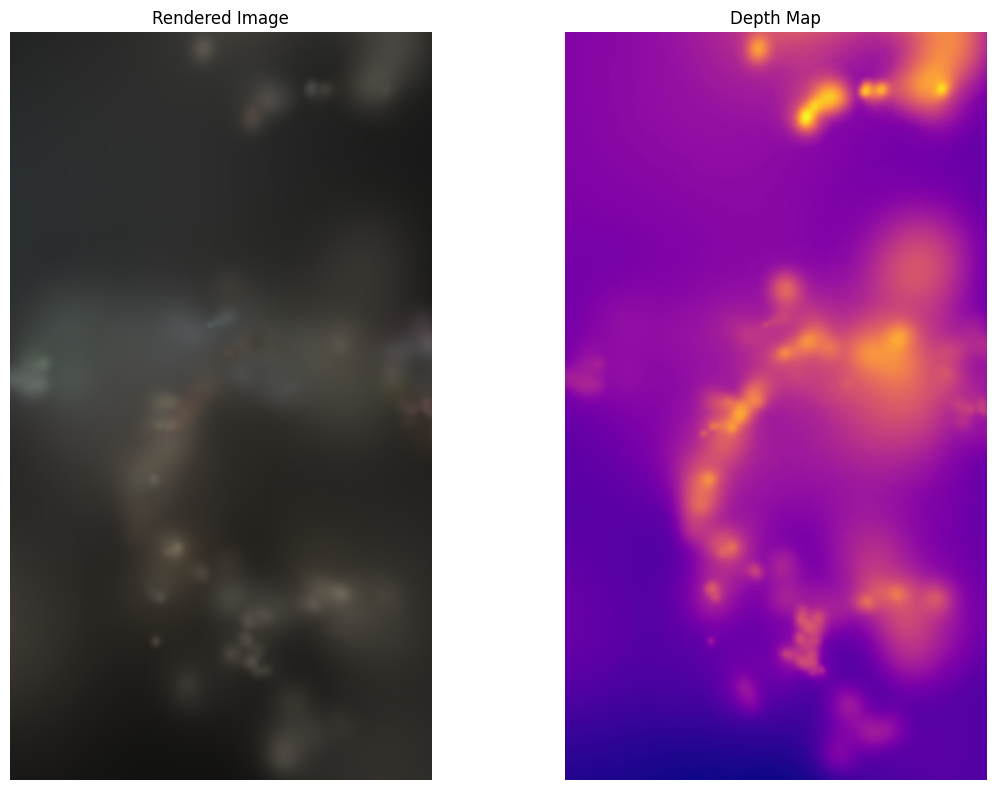

In [26]:
import matplotlib.pyplot as plt

rgb = out["render"].detach().cpu().numpy().transpose(1, 2, 0)
depth = out["depth"].detach().cpu().numpy()
if depth.ndim == 3 and depth.shape[0] == 1:
    depth = depth.squeeze(0)

fig, axes = plt.subplots(1, 2, figsize=(12, 8))

axes[0].imshow(rgb)
axes[0].set_title("Rendered Image")
axes[0].axis("off")

axes[1].imshow(depth, cmap="plasma")
axes[1].set_title("Depth Map")
axes[1].axis("off")

plt.tight_layout()
plt.show()
